In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import pandas as pd
from networkx.algorithms import community

### Funzione draw()

In [3]:
def draw(G, pos, measures, measure_name):
    
    nodes = nx.draw_networkx_nodes(G, pos, node_size=250, cmap=plt.cm.plasma, 
                                   node_color=list(measures.values()),
                                   nodelist=measures.keys())
    nodes.set_norm(mcolors.SymLogNorm(linthresh=0.01, linscale=1))
    
    # labels = nx.draw_networkx_labels(G, pos)
    edges = nx.draw_networkx_edges(G, pos)

    plt.title(measure_name)
    plt.colorbar(nodes)
    plt.axis('off')
    plt.show()

### Creazione grafo

In [21]:
hero_network_dataframe = pd.read_csv("../data/raw/dati marvel/hero-network.csv")
edges = list(zip(hero_network_dataframe["hero1"], hero_network_dataframe["hero2"]))

hero_graph = nx.from_pandas_edgelist(hero_network_dataframe, source="hero1", target="hero2")

hero_graph = nx.Graph()
hero_graph.add_edges_from(edges)
pos = nx.spring_layout(hero_graph)

print("NODES: ", len(hero_graph.nodes))
print("EDGES: ", len(hero_graph.edges))
print("CLUSTERING: ", nx.average_clustering(hero_graph))

NODES:  6426
EDGES:  167219
CLUSTERING:  0.774654121711063


<Axes: >

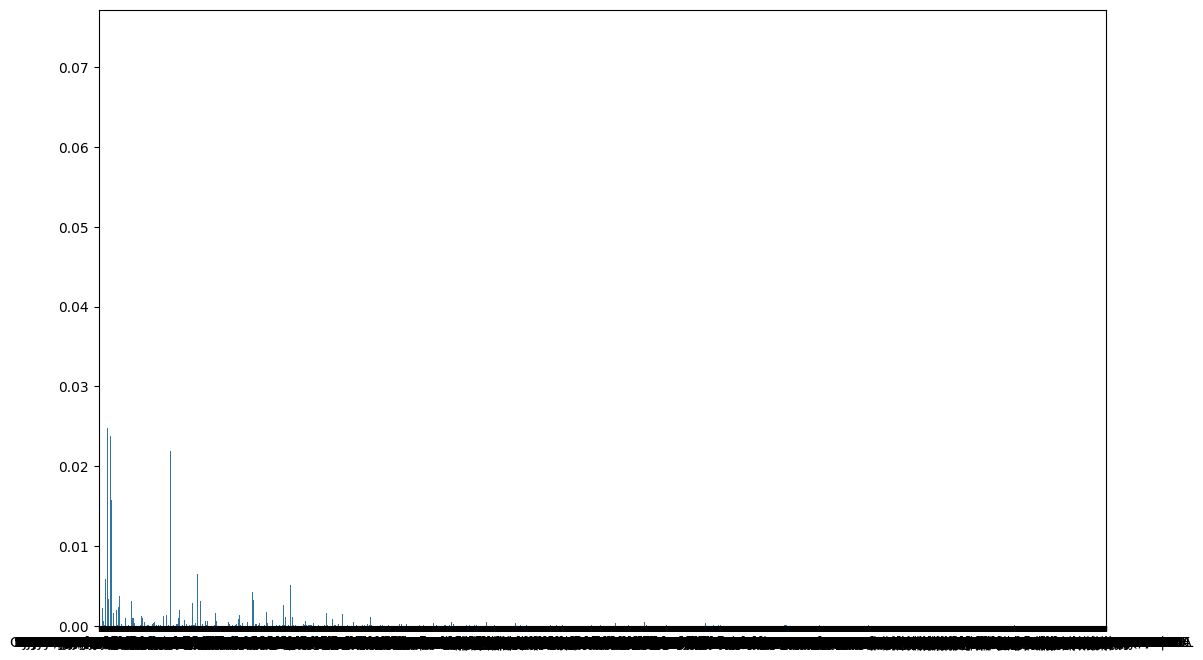

In [22]:
bet = nx.betweenness_centrality(hero_graph)
plt.figure(figsize=(13,8))
sns.barplot(x=list(bet.keys()), y=list(bet.values()))

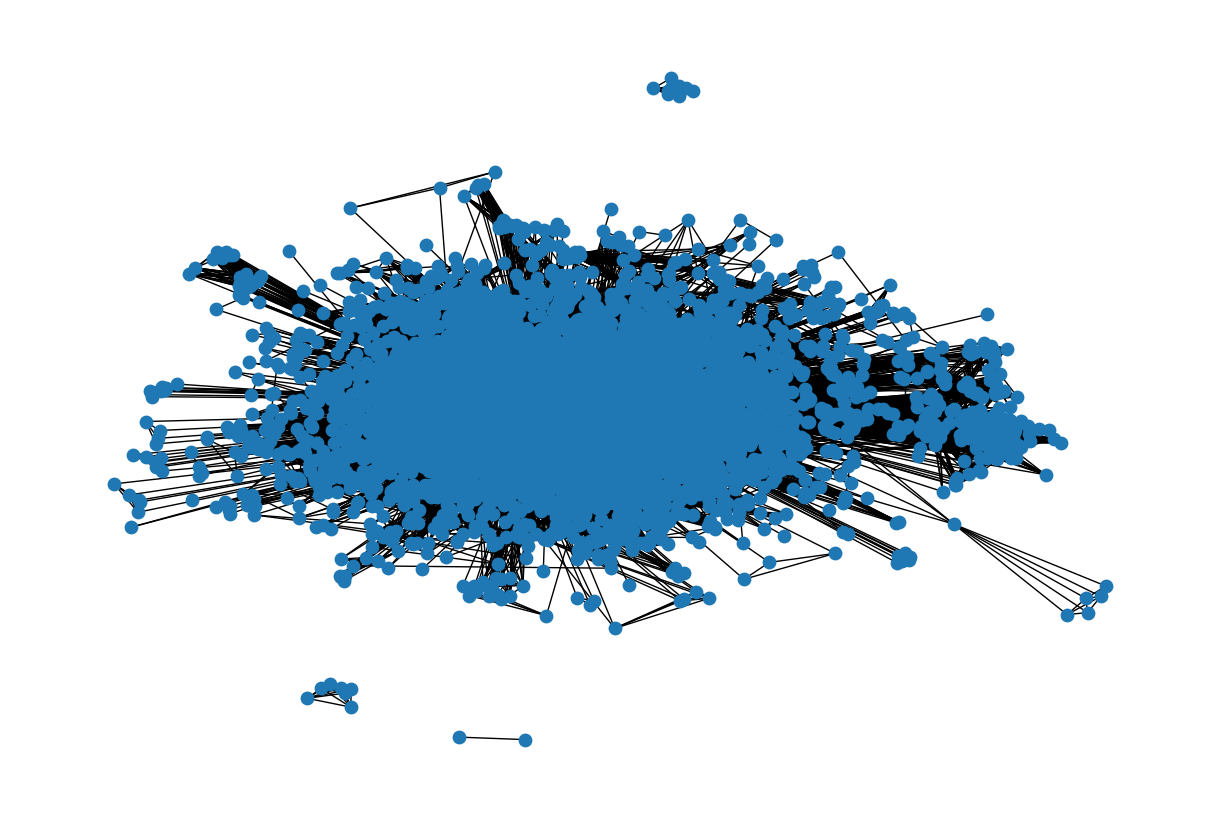

In [32]:
plt.figure(figsize=(12,8))
# nx.draw(hero_graph, pos)
# nx.draw(hero_graph, pos, with_labels=True, node_color='lightblue', node_size=150, font_size=8) --> completo ma non si capisce niente
nx.draw(hero_graph, pos, node_size=80) 
plt.show()

<Figure size 1500x1000 with 0 Axes>

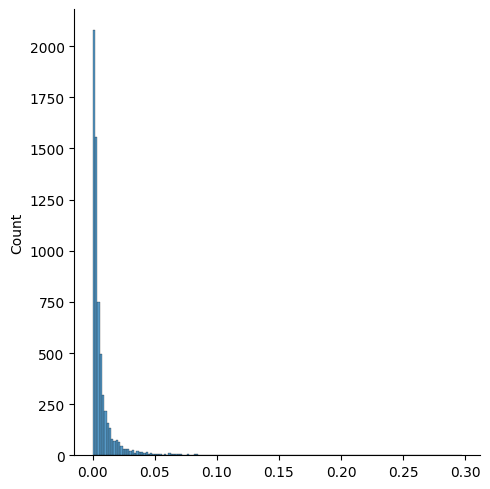

In [12]:
degree = nx.degree_centrality(hero_graph)
plt.figure(figsize=(15,10))
sns.displot(list(degree.values()), kde=False)

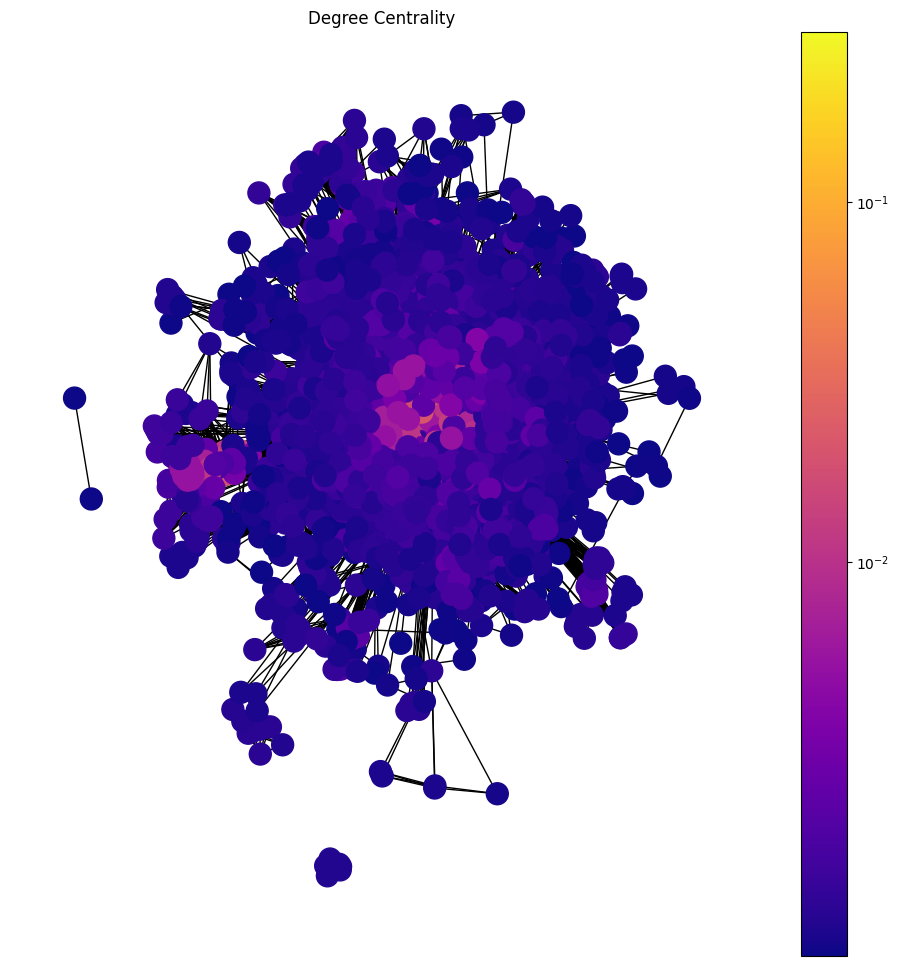

In [13]:
plt.figure(figsize=(12,12))
pos = nx.spring_layout(hero_graph)
draw(hero_graph, pos, degree, 'Degree Centrality')

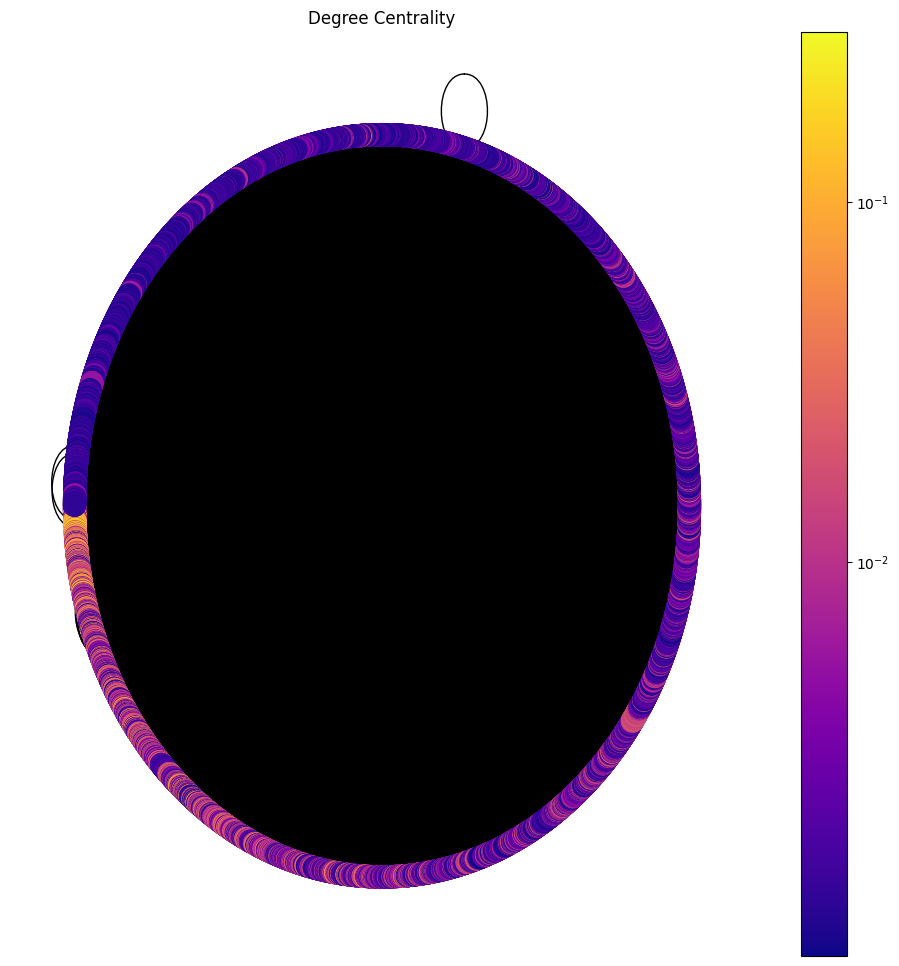

In [16]:
plt.figure(figsize=(12,12))
pos = nx.shell_layout(hero_graph)
draw(hero_graph, pos, degree, 'Degree Centrality')

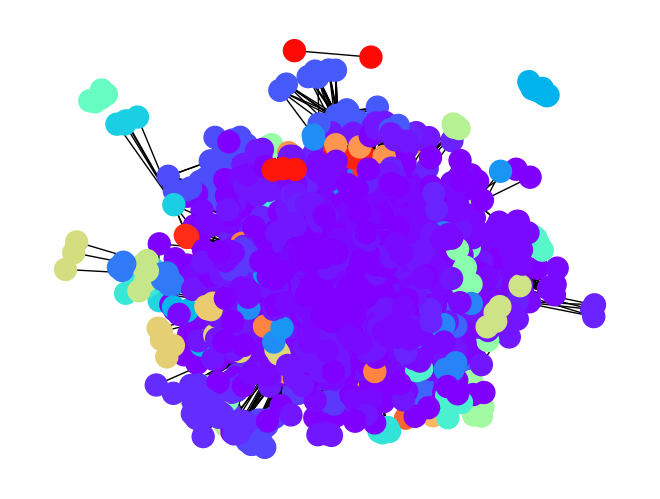

In [20]:
communities = community.greedy_modularity_communities(hero_graph)



colors = plt.cm.rainbow([i / len(communities) for i in range(len(communities))])
node_colors = {}


for color, community_nodes in zip(colors, communities):
    for node in community_nodes:
        node_colors[node] = color


pos = nx.spring_layout(hero_graph)
nx.draw(hero_graph, pos, node_color=[node_colors[node] for node in hero_graph.nodes], with_labels=False, node_size=250)
plt.show()